In [1]:
import superstats as sup
import bayesflow as bf
import numpy as np

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
E0717 00:13:17.610465   66592 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
INFO:bayesflow:Using backend 'jax'


## Constants

In [2]:
NUM_STEPS = 100
NUM_SAMPLES = 500
NUM_EPOCHS = 100
BATCH_SIZE = 32

## Prior

In [3]:
joint_prior = sup.prior.JointPrior(
    v = sup.transition.RandomWalk(
            bounds=(0.0, 6.0),
            sigma=sup.prior.Prior(dist="halfnormal", scale=0.1),
            delta=0,
            initial_prior=sup.prior.Prior(dist="normal", loc=-1.5, scale=0.5)
        ),
    a = sup.transition.RandomWalk(
            bounds=(0.0, 4.0),
            sigma=sup.prior.Prior(dist="halfnormal", scale=0.1),
            delta=0,
            initial_prior=sup.prior.Prior(dist="normal", loc=0.0, scale=0.5)
        ),
    tau = sup.transition.RandomWalk(
            bounds=(0.0, 2.0),
            sigma=sup.prior.Prior(dist="halfnormal", scale=0.1),
            delta=0,
            initial_prior=sup.prior.Prior(dist="normal", loc=-1.5, scale=0.5)
        ),
    bias = 0.5
)

generative_model = sup.simulation.GenerativeModel(
    prior=joint_prior,
    model=sup.simulation.sample_ddm,
    missing="random"
)

## Workflow

In [5]:
workflow = sup.workflow.Workflow(
    simulator=generative_model,
    summary_network=sup.networks.RecurrentNet(time_embed_dim=16)
)

## Training

In [6]:
training_data = generative_model.sample(10_000, num_steps=NUM_STEPS, tile_to_steps=True)
val_data = generative_model.sample(100, num_steps=NUM_STEPS, tile_to_steps=True)

In [7]:
history = workflow.fit_offline(
    data=training_data,
    validation_data=val_data,
    epochs=50,
    batch_size=BATCH_SIZE
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/50


E0717 00:14:11.115486   66610 cuda_timer.cc:88] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 55ms/step - loss: 7.0761 - val_loss: 5.9991
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 5.9339 - val_loss: 5.6973
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 5.4106 - val_loss: 5.2578
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 4.9839 - val_loss: 4.9111
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 4.6949 - val_loss: 4.6059
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 4.4154 - val_loss: 4.2776
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 4.2625 - val_loss: 4.2832
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 4.1029 - val_loss: 4.0731
Epoch 9/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 3.9890 - val_loss: 4.0509
Epoch 10/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 3.9002 - val_loss: 3.9705
Epoch 11/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 3.8311 - val_loss: 3.9980
Epoch 12/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/st

INFO:bayesflow:Training completed in 3.70 minutes.


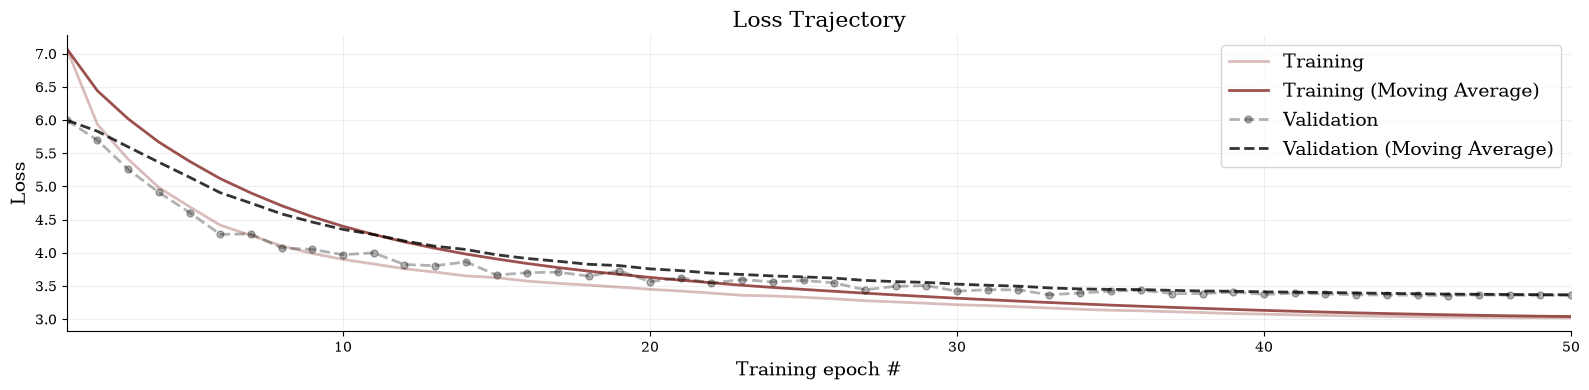

In [8]:
fig = workflow.plot_history(workflow.history)

## Verification

In [9]:
test_data = workflow.simulator.sample(
    batch_size=100,
    num_steps=NUM_STEPS,
    tile_to_steps=False
)

In [10]:
samples = workflow.sample(
    data=test_data,
    num_samples=300,
    batch_size=8
)

Summarizing:   0%|          | 0/13 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/13 [00:00<?, ?batch/s]

### Time-varying Parameters

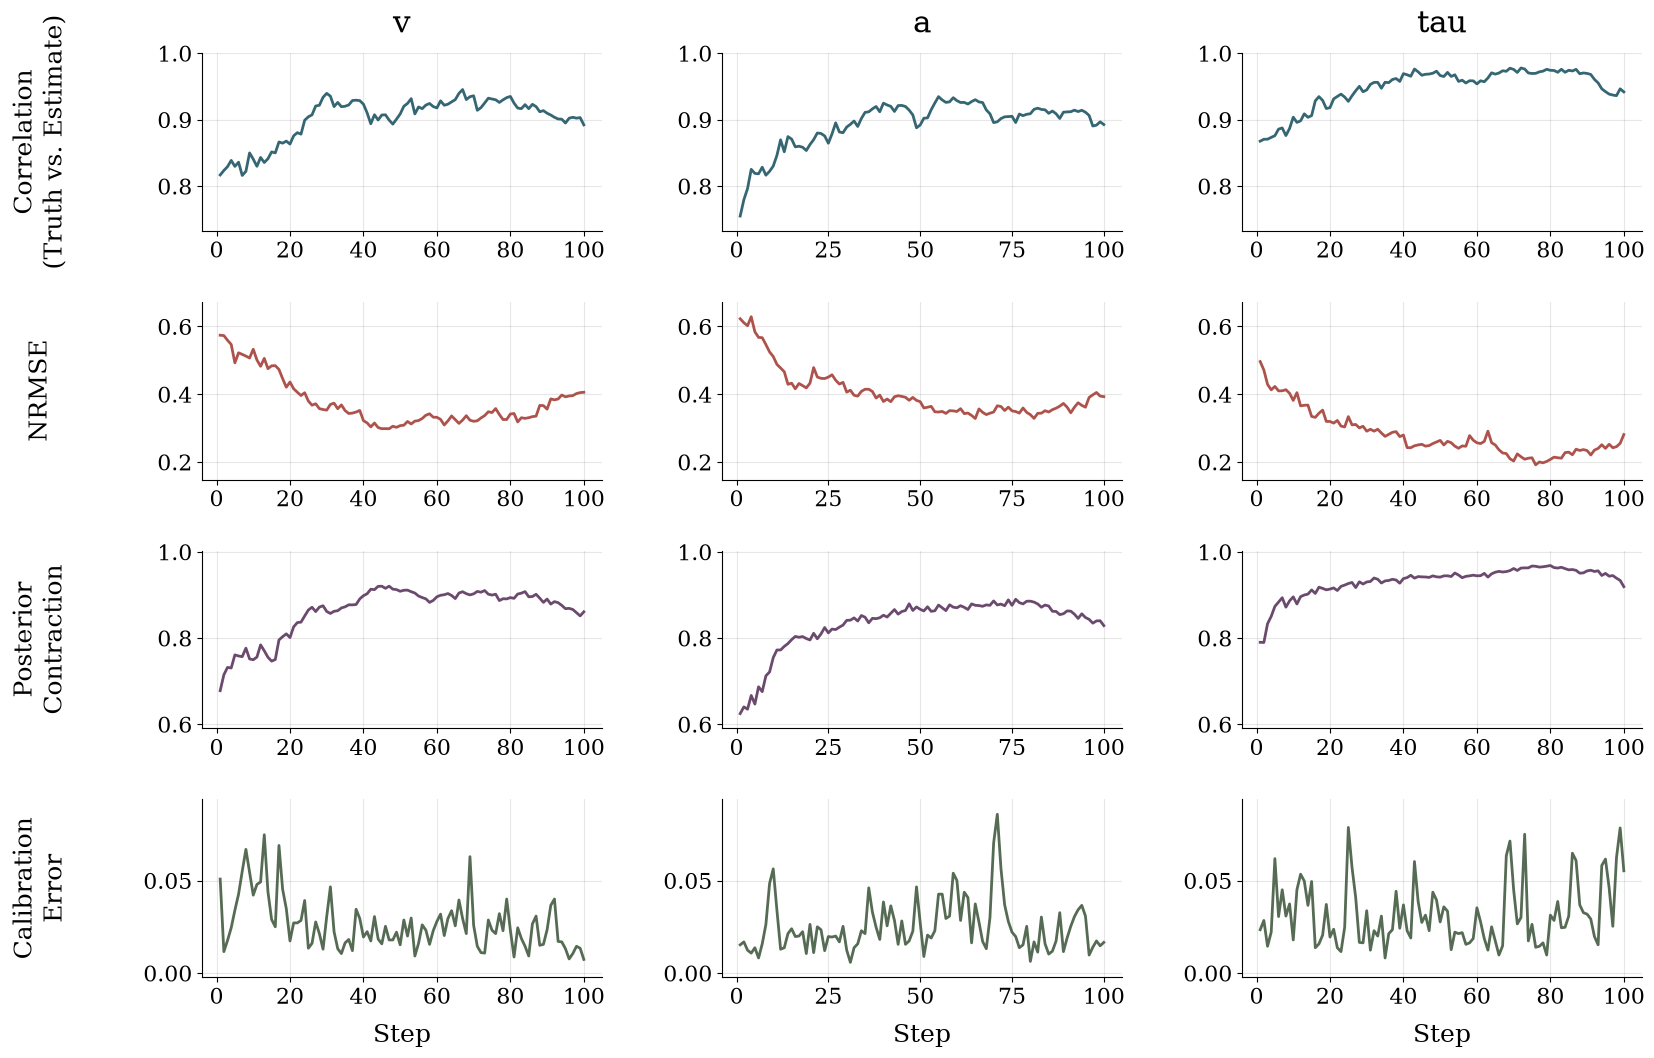

In [12]:
fig = workflow.verify_time_varying(test_data, samples)

In [13]:
time_step = 99
local_keys = workflow.simulator.local_keys
true = np.stack([test_data[k][:, time_step, 0] for k in local_keys], axis=-1)
estimates = np.stack([samples[k][:, :, time_step, 0] for k in local_keys], axis=-1)

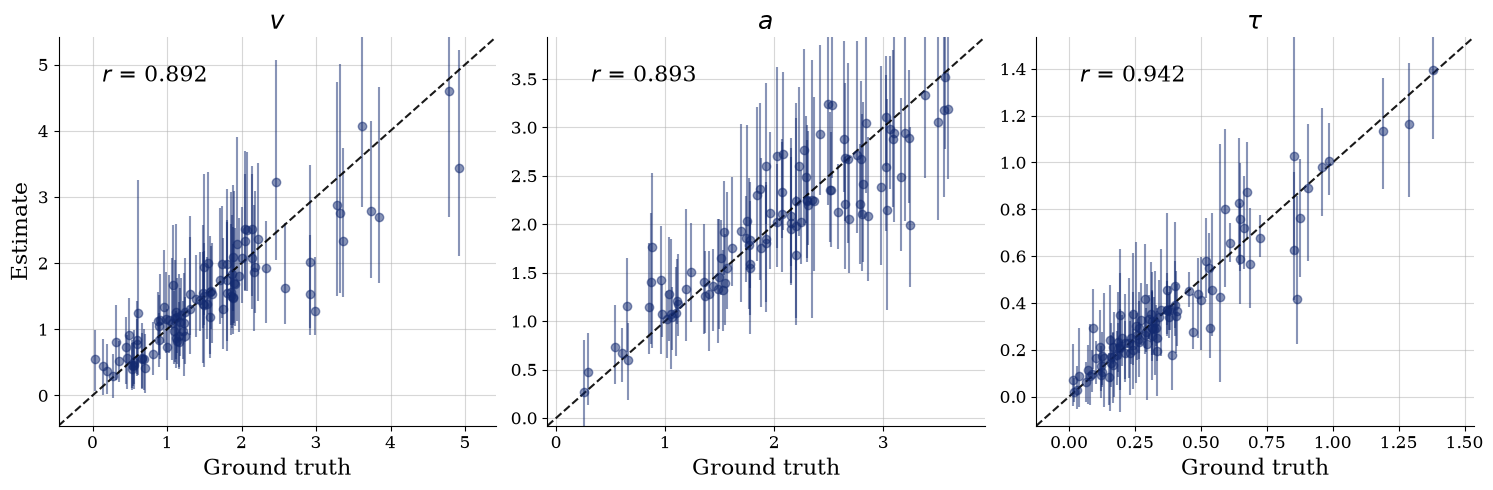

In [14]:
fig = bf.diagnostics.plots.recovery(
    estimates,
    true,
    variable_names = [r"$v$", r"$a$", r"$\tau$"],
)

### Time-invariant Parameters

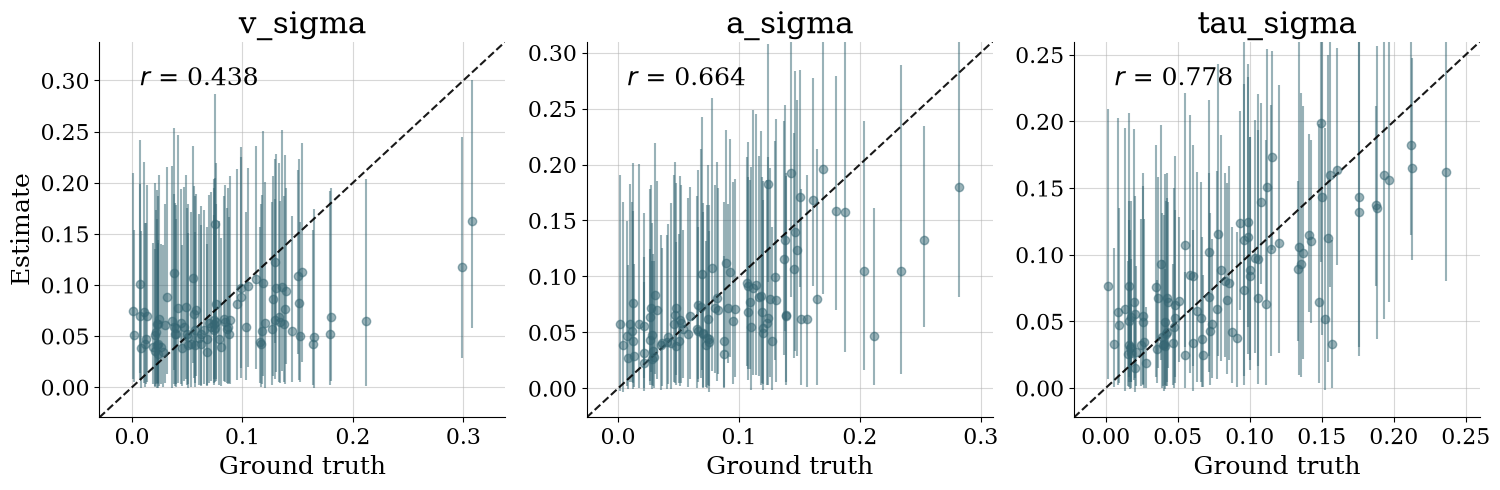

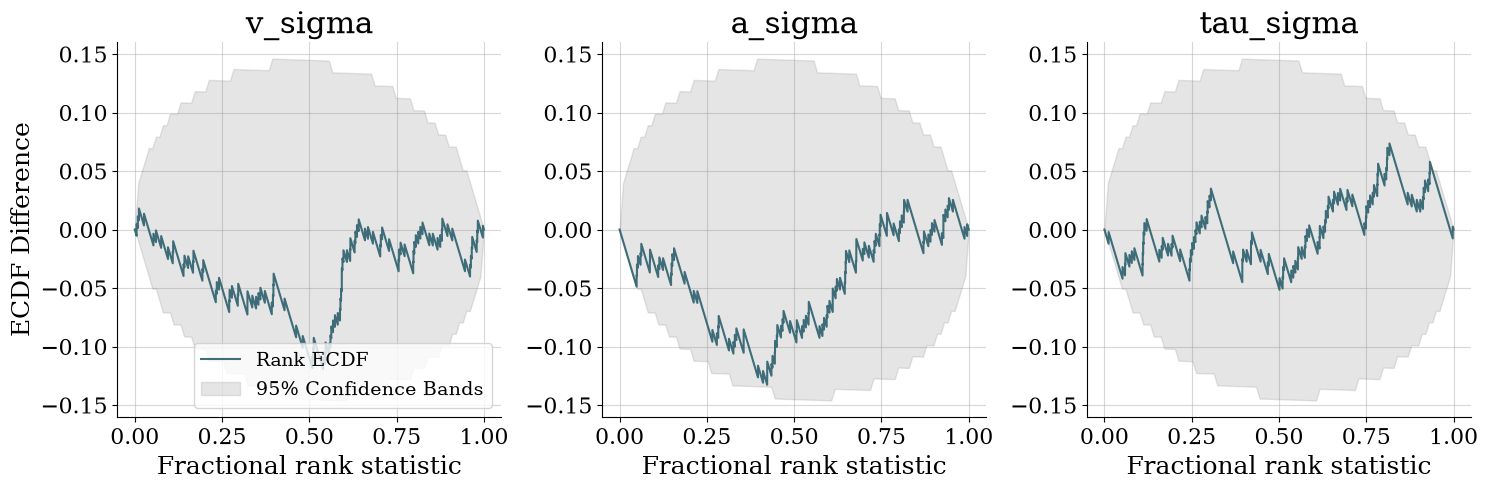

In [15]:
fig_recovery, fig_calibration = workflow.verify_time_invariant(
    test_data,
    samples
)